In [1]:
%load_ext autoreload
%autoreload 2


## Libraries

In [2]:
# Add root to path
import sys


sys.path.append("..")

from component.script.project import Project
from component.script.geo_utils import calculate_utm_rioxarray
from component.script.variables.models import RasterType


## Load project

In [3]:
project_name = "mtq-refactor"

# Load the project from JSON
project = Project.load(project_name=project_name)
project.reset()


✓ Target set: forest_loss_2020_2024 (static)
  ⚠ Dataset 'validation': feature(s) not found in processed variables, skipped: ['forest_gfc_edge', 'rivers_dist', 'roads_dist', 'towns_dist']
✓ Features set: 5 variables
  Static: altitude, protected_area, slope, subj
  Temporal (year: 2024): forest_gfc
✓ Target set: forest_loss_2015_2020 (static)
  ⚠ Dataset 'calibration': feature(s) not found in processed variables, skipped: ['forest_gfc_edge', 'rivers_dist', 'roads_dist', 'towns_dist']
✓ Features set: 5 variables
  Static: altitude, protected_area, slope, subj
  Temporal (year: 2020): forest_gfc
Loaded 2 dataset(s)
Project loaded from: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json
Loaded 15 processed variables
⚠️  WARNING: About to remove 15 processed variable(s) from project
✓ Removed 15 processed variable(s)

✅ Total removed: 15 variable(s)
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-n

15

## Define base variable

The base variable will be uses as reference for all other variables in terms of resolution, crs and extent.

In [4]:
# First, we list all the raster files in the project directory
project.raw_variables


{'subj': LocalRasterVar(name='subj', data_type='raster', year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data_raw/subj.tif'), raster_type='categorical', post_processing=[], processing_history=[], default_crs=None, default_resolution=None),
 'protected_area': LocalRasterVar(name='protected_area', data_type='raster', year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data_raw/protected_area.tif'), raster_type='categorical', post_processing=[], processing_history=[], default_crs=None, default_resolution=None),
 'altitude': LocalRasterVar(name='altitude', data_type='raster', year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data_raw/altitude.tif'), raster_type='continuous', post_processing=[], processing_history=[], default_crs=None, defa

In [5]:
# We select the name of the variable we want to use

base_layer_name = "subj"  # We can change this if our base has a different name
base_variable = project.raw_variables[base_layer_name]


In [6]:
user_defined_epsg_code = "EPSG:5490"  # or write "EPSG:3116"


In [7]:
# If the user has not defined an EPSG code, we calculate it from the base variable
if user_defined_epsg_code is None:
    calculated_epsg = calculate_utm_rioxarray(base_variable.path)
    epsg_code = calculated_epsg
elif user_defined_epsg_code is not None:
    epsg_code = user_defined_epsg_code

print(f"Using EPSG:{epsg_code} for reprojection.")


Using EPSG:EPSG:5490 for reprojection.


In [8]:
# Reproject the base variable to the calculated or user-defined EPSG code
# This will be the reference for all other variables
reprojected_base = base_variable.reproject(target_epsg=epsg_code)


In [9]:
# We call a method to make this var the base of our project
reprojected_base.use_as_base_raster()


✓ Set 'subj' as base raster for project 'mtq-refactor'
  Path: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data/subj_reprojected.tif
  CRS: EPSG:5490
  Resolution: 30
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json


LocalRasterVar(name='subj', data_type=<DataType.raster: 'raster'>, year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data/subj_reprojected.tif'), raster_type='categorical', post_processing=[], processing_history=['reprojected'], default_crs='EPSG:5490', default_resolution=30)

In [10]:
project.base_raster


LocalRasterVar(name='subj', data_type=<DataType.raster: 'raster'>, year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data/subj_reprojected.tif'), raster_type='categorical', post_processing=[], processing_history=['reprojected'], default_crs='EPSG:5490', default_resolution=30)

## Create the target variables

In [11]:
calculate_forest_loss = True
calculate_forest_loss_stack = True


In [12]:
from component.script.processing import get_forest_loss_calculated
from component.script.variables import LocalRasterVar

# Our goal is to train a model that fits the deforestation which ocurrend in a period of time
# For that, we need to create a target variable that represents the deforestation in that period

if calculate_forest_loss:
    forest_layers = project.filter_by_tags(["forest"], look_up_in="raw")
    forest_layers = [layer for layer in forest_layers.values()]

    forest_loss_layers = get_forest_loss_calculated(project, forest_layers)

    # now we add the new layers to the project
    for layer in forest_loss_layers:
        layer: LocalRasterVar
        # Raw because we have not projected it yet
        layer.add_as_raw()


Calculating forest loss between 2015 and 2020...
Calculating forest loss between 2015 and 2024...
Calculating forest loss between 2020 and 2024...
✓ Forest loss calculation complete!
✓ Added 'forest_loss_2015_2020' to raw variables (key: forest_loss_2015_2020)
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json
✓ Added 'forest_loss_2015_2024' to raw variables (key: forest_loss_2015_2024)
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json
✓ Added 'forest_loss_2020_2024' to raw variables (key: forest_loss_2020_2024)
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json


/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/.venv/lib/python3.11/site-packages/rasterio/warp.py:344: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  _reproject(


In [13]:
project.filter_by_tags(["forest"], look_up_in="raw")


{'forest_gfc_2015': LocalRasterVar(name='forest_gfc', data_type='raster', year=2015, active=True, tags=['forest'], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data_raw/forest_gfc_2015.tif'), raster_type='categorical', post_processing=[], processing_history=[], default_crs=None, default_resolution=None),
 'forest_gfc_2020': LocalRasterVar(name='forest_gfc', data_type='raster', year=2020, active=True, tags=['forest'], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data_raw/forest_gfc_2020.tif'), raster_type='categorical', post_processing=[], processing_history=[], default_crs=None, default_resolution=None),
 'forest_gfc_2024': LocalRasterVar(name='forest_gfc', data_type='raster', year=2024, active=True, tags=['forest'], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data_raw/forest_gfc_2024.tif'), raster_type='categorical'

In [14]:
forest_loss_layers


[LocalRasterVar(name='forest_loss_2015_2020', data_type=<DataType.raster: 'raster'>, year=None, active=True, tags=['deforestation', 'forest_loss', '2015_2020'], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data_raw/forest_loss_2015_2020.tif'), raster_type='categorical', post_processing=[], processing_history=[], default_crs=None, default_resolution=None),
 LocalRasterVar(name='forest_loss_2015_2024', data_type=<DataType.raster: 'raster'>, year=None, active=True, tags=['deforestation', 'forest_loss', '2015_2024'], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data_raw/forest_loss_2015_2024.tif'), raster_type='categorical', post_processing=[], processing_history=[], default_crs=None, default_resolution=None),
 LocalRasterVar(name='forest_loss_2020_2024', data_type=<DataType.raster: 'raster'>, year=None, active=True, tags=['deforestation', 'forest_loss', '2020_2024'], path=Posi

In [15]:
project.filter_by_attrs("raw", tags="deforestation")


{'forest_loss_2015_2020': LocalRasterVar(name='forest_loss_2015_2020', data_type=<DataType.raster: 'raster'>, year=None, active=True, tags=['deforestation', 'forest_loss', '2015_2020'], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data_raw/forest_loss_2015_2020.tif'), raster_type='categorical', post_processing=[], processing_history=[], default_crs=None, default_resolution=None),
 'forest_loss_2015_2024': LocalRasterVar(name='forest_loss_2015_2024', data_type=<DataType.raster: 'raster'>, year=None, active=True, tags=['deforestation', 'forest_loss', '2015_2024'], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data_raw/forest_loss_2015_2024.tif'), raster_type='categorical', post_processing=[], processing_history=[], default_crs=None, default_resolution=None),
 'forest_loss_2020_2024': LocalRasterVar(name='forest_loss_2020_2024', data_type=<DataType.raster: 'raster'>, year=None,

## Reproject and Rasterize Vector Data

In [16]:
project.raw_variables


{'subj': LocalRasterVar(name='subj', data_type='raster', year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data_raw/subj.tif'), raster_type='categorical', post_processing=[], processing_history=[], default_crs=None, default_resolution=None),
 'protected_area': LocalRasterVar(name='protected_area', data_type='raster', year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data_raw/protected_area.tif'), raster_type='categorical', post_processing=[], processing_history=[], default_crs=None, default_resolution=None),
 'altitude': LocalRasterVar(name='altitude', data_type='raster', year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data_raw/altitude.tif'), raster_type='continuous', post_processing=[], processing_history=[], default_crs=None, defa

In [17]:
# Finally, we reproject all the variables to match the base variable
project.processed_variables = {}  # Make sure we clear raw variables to avoid showing them twice
project.reproject_and_match_all()



📍 Reprojecting 'subj'...
✓ Added 'subj' to processed variables (key: subj)
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json

📍 Reprojecting 'protected_area'...
✓ Added 'protected_area' to processed variables (key: protected_area)
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json

📍 Reprojecting 'altitude'...
✓ Added 'altitude' to processed variables (key: altitude)
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json

📍 Reprojecting 'slope'...
✓ Added 'slope' to processed variables (key: slope)
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json

📍 Reprojecting 'forest_gfc_2015'...
✓ Added 'forest_gfc' to processed variables (key: forest_gfc_2015)
Project saved to: /home/jos

{'subj': LocalRasterVar(name='subj', data_type=<DataType.raster: 'raster'>, year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data/subj_reprojected_matched.tif'), raster_type='categorical', post_processing=[], processing_history=['reprojected_matched'], default_crs='EPSG:5490', default_resolution=30.0),
 'protected_area': LocalRasterVar(name='protected_area', data_type=<DataType.raster: 'raster'>, year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data/protected_area_reprojected_matched.tif'), raster_type='categorical', post_processing=[], processing_history=['reprojected_matched'], default_crs='EPSG:5490', default_resolution=30.0),
 'altitude': LocalRasterVar(name='altitude', data_type=<DataType.raster: 'raster'>, year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jup

In [18]:
# Rasterize will also also set the new projection and match the base raster
project.rasterize_all()



✅ Rasterized 0 vector variables


{}

In [19]:
project.processed_vars


{'subj': LocalRasterVar(name='subj', data_type=<DataType.raster: 'raster'>, year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data/subj_reprojected_matched.tif'), raster_type='categorical', post_processing=[], processing_history=['reprojected_matched'], default_crs='EPSG:5490', default_resolution=30.0),
 'protected_area': LocalRasterVar(name='protected_area', data_type=<DataType.raster: 'raster'>, year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data/protected_area_reprojected_matched.tif'), raster_type='categorical', post_processing=[], processing_history=['reprojected_matched'], default_crs='EPSG:5490', default_resolution=30.0),
 'altitude': LocalRasterVar(name='altitude', data_type=<DataType.raster: 'raster'>, year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jup

## Calculate distance

In [20]:
forest_vars = project.filter_by_attrs(name="forest_gfc", source="processed")
for var in forest_vars.values():
    var.apply_post_processing("edge").add_as_processed()


✓ Added 'forest_gfc_edge' to processed variables (key: forest_gfc_edge_2015)
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json
✓ Added 'forest_gfc_edge' to processed variables (key: forest_gfc_edge_2020)
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json
✓ Added 'forest_gfc_edge' to processed variables (key: forest_gfc_edge_2024)
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json


In [21]:
river_vars = project.filter_by_attrs(name="rivers", source="processed")
for var in river_vars.values():
    var.apply_post_processing("dist").add_as_processed()


road_vars = project.filter_by_attrs(name="roads", source="processed")
for var in road_vars.values():
    var.apply_post_processing("dist").add_as_processed()

town_vars = project.filter_by_attrs(name="towns", source="processed")
for var in town_vars.values():
    var.apply_post_processing("dist").add_as_processed()


✓ Added 'rivers_dist' to processed variables (key: rivers_dist)
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json
✓ Added 'roads_dist' to processed variables (key: roads_dist)
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json
✓ Added 'towns_dist' to processed variables (key: towns_dist_2015)
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json
✓ Added 'towns_dist' to processed variables (key: towns_dist_2020)
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json
✓ Added 'towns_dist' to processed variables (key: towns_dist_2024)
Project saved to: /home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/mtq-refactor_project.json


In [22]:
project.processed_vars


{'subj': LocalRasterVar(name='subj', data_type=<DataType.raster: 'raster'>, year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data/subj_reprojected_matched.tif'), raster_type='categorical', post_processing=[], processing_history=['reprojected_matched'], default_crs='EPSG:5490', default_resolution=30.0),
 'protected_area': LocalRasterVar(name='protected_area', data_type=<DataType.raster: 'raster'>, year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jupyter-nb-v2/data/mtq-refactor/data/protected_area_reprojected_matched.tif'), raster_type='categorical', post_processing=[], processing_history=['reprojected_matched'], default_crs='EPSG:5490', default_resolution=30.0),
 'altitude': LocalRasterVar(name='altitude', data_type=<DataType.raster: 'raster'>, year=None, active=True, tags=[], path=PosixPath('/home/jose/workspace/deforisk-nb-with-daniel/deforisk-jup

In [23]:
list(project.processed_vars.keys())


['subj',
 'protected_area',
 'altitude',
 'slope',
 'forest_gfc_2015',
 'forest_gfc_2020',
 'forest_gfc_2024',
 'rivers',
 'roads',
 'towns_2015',
 'towns_2020',
 'towns_2024',
 'forest_loss_2015_2020',
 'forest_loss_2015_2024',
 'forest_loss_2020_2024',
 'forest_gfc_edge_2015',
 'forest_gfc_edge_2020',
 'forest_gfc_edge_2024',
 'rivers_dist',
 'roads_dist',
 'towns_dist_2015',
 'towns_dist_2020',
 'towns_dist_2024']

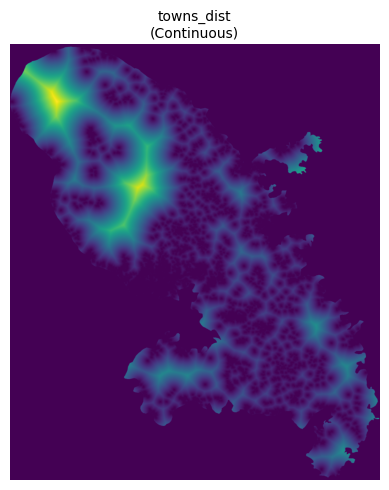

In [24]:
project.processed_vars["towns_dist_2020"].show()
